# 03 — Predictive Modeling & Model Interpretability (Lớp 3: Phân tích Dự đoán)

**Thành viên thực hiện**: Nguyễn Anh Hào (MSSV: 52400186) — Machine Learning Engineer  
**Đề tài**: Phân tích điểm đen tai nạn giao thông đô thị  
**Mục tiêu**:
1. Xây dựng mô hình học máy dự đoán mức độ nghiêm trọng của tai nạn (`Severity`).
2. So sánh hiệu năng giữa mô hình cơ sở (**Baseline: Logistic Regression**) và mô hình nâng cao (**Advanced: XGBoost Classifier**).
3. Triển khai các kỹ thuật diễn giải mô hình (**Model Interpretability: Feature Importance, Permutation Importance & SHAP Values**) để giải thích nguyên nhân tác động đến mức độ nghiêm trọng của tai nạn giao thông.


## 1. Import Thư viện & Thiết lập Môi trường


In [5]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)
from sklearn.inspection import permutation_importance

# Advanced Models
import xgboost as xgb
from xgboost import XGBClassifier

# Style plotting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Đã import thành công toàn bộ thư viện Machine Learning!")


Đã import thành công toàn bộ thư viện Machine Learning!


## 2. Nạp Dữ liệu Train / Test


In [6]:
# Xác định đường dẫn thư mục data an toàn
cwd = Path.cwd()
project_root = cwd if (cwd / "data").is_dir() else (cwd.parent if (cwd.parent / "data").is_dir() else cwd)
DATA_DIR = (project_root / "data").resolve()

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

assert train_path.exists(), f"Không tìm thấy file {train_path}. Vui lòng chạy 01_data_cleaning.ipynb trước."
assert test_path.exists(), f"Không tìm thấy file {test_path}. Vui lòng chạy 01_data_cleaning.ipynb trước."

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("=" * 70)
print("THÔNG TIN DỮ LIỆU ĐẦU VÀO")
print("=" * 70)
print("Tập Train shape :", train_df.shape)
print("Tập Test shape  :", test_df.shape)
print("Phân bố Severity trong Train:")
print(train_df['Severity'].value_counts(normalize=True).round(4) * 100)
print("=" * 70)


THÔNG TIN DỮ LIỆU ĐẦU VÀO
Tập Train shape : (2243729, 36)
Tập Test shape  : (594578, 36)
Phân bố Severity trong Train:
Severity
2    88.48
3     7.92
4     2.06
1     1.53
Name: proportion, dtype: float64


## 2.5. Khảo sát Biểu diễn Dữ liệu & Lý do Lựa chọn Đặc trưng (Feature Selection Rationale)

Để mô hình học máy đạt hiệu năng cao và tránh hiện tượng **Rò rỉ Dữ liệu (Data Leakage)** hoặc **Bùng nổ chiều không gian (Curse of Dimensionality)**, việc biểu diễn khảo sát mối tương quan và lựa chọn đặc trưng được thực hiện theo tiêu chí nghiệp vụ nghiêm ngặt:

### 1. Bảng Tiêu chí Lựa chọn / Loại bỏ Thuộc tính:
- **TÍNH NĂNG ĐƯỢC GIỮ LẠI (SELECTED FEATURES)**:
  - **Nhóm Thời tiết & Khí hậu**: `Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)`, `Wind_Speed(mph)`, `Precipitation(in)`, `Weather_Group`, `Is_Adverse_Weather`, `Is_Low_Visibility`. *(Lý do: Tác động trực tiếp đến hệ số ma sát lốp xe và tầm nhìn quan sát của người lái)*.
  - **Nhóm Hạ tầng Đường bộ (POI)**: `Junction`, `Crossing`, `Traffic_Signal`, `Railway`, `Stop`, `Amenity`. *(Lý do: Các mốc xung đột luồng giao thông dễ gây ra tai nạn dây chuyền nghiêm trọng)*.
  - **Nhóm Thời gian & Vị trí**: `Hour`, `Month`, `Season`, `DayOfWeek`, `Start_Lat`, `Start_Lng`, `State`. *(Lý do: Đại diện cho mật độ lưu lượng xe giờ cao điểm và khu vực địa lý)*.
- **THUỘC TÍNH LOẠI BỎ (DROPPED FEATURES)**:
  - `ID`: Mã định danh duy nhất (không chứa thông tin dự báo).
  - `Start_Time`, `End_Time` (chuỗi thô): Đã trích xuất thành `Hour`, `Month`, `Season`, `DayOfWeek` phục vụ mô hình hóa.
  - `City`, `County`, `Zipcode`: Nhãn định tính có quá nhiều giá trị duy nhất (High-cardinality), nếu mã hóa One-Hot sẽ làm tăng đột biến hàng nghìn chiều dữ liệu, gây lãng phí bộ nhớ và mô hình dễ bị overfitting.

### 2. Trực quan hóa Phân phối & Heatmap Tương quan:


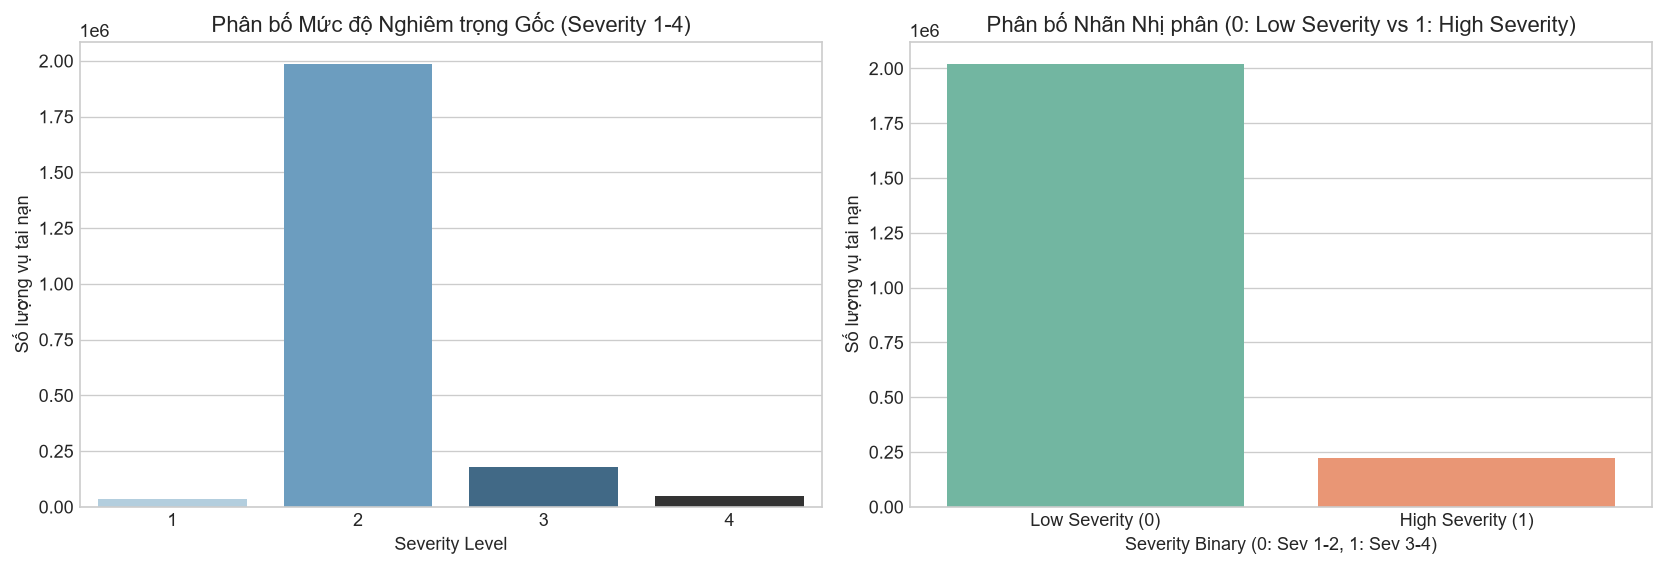

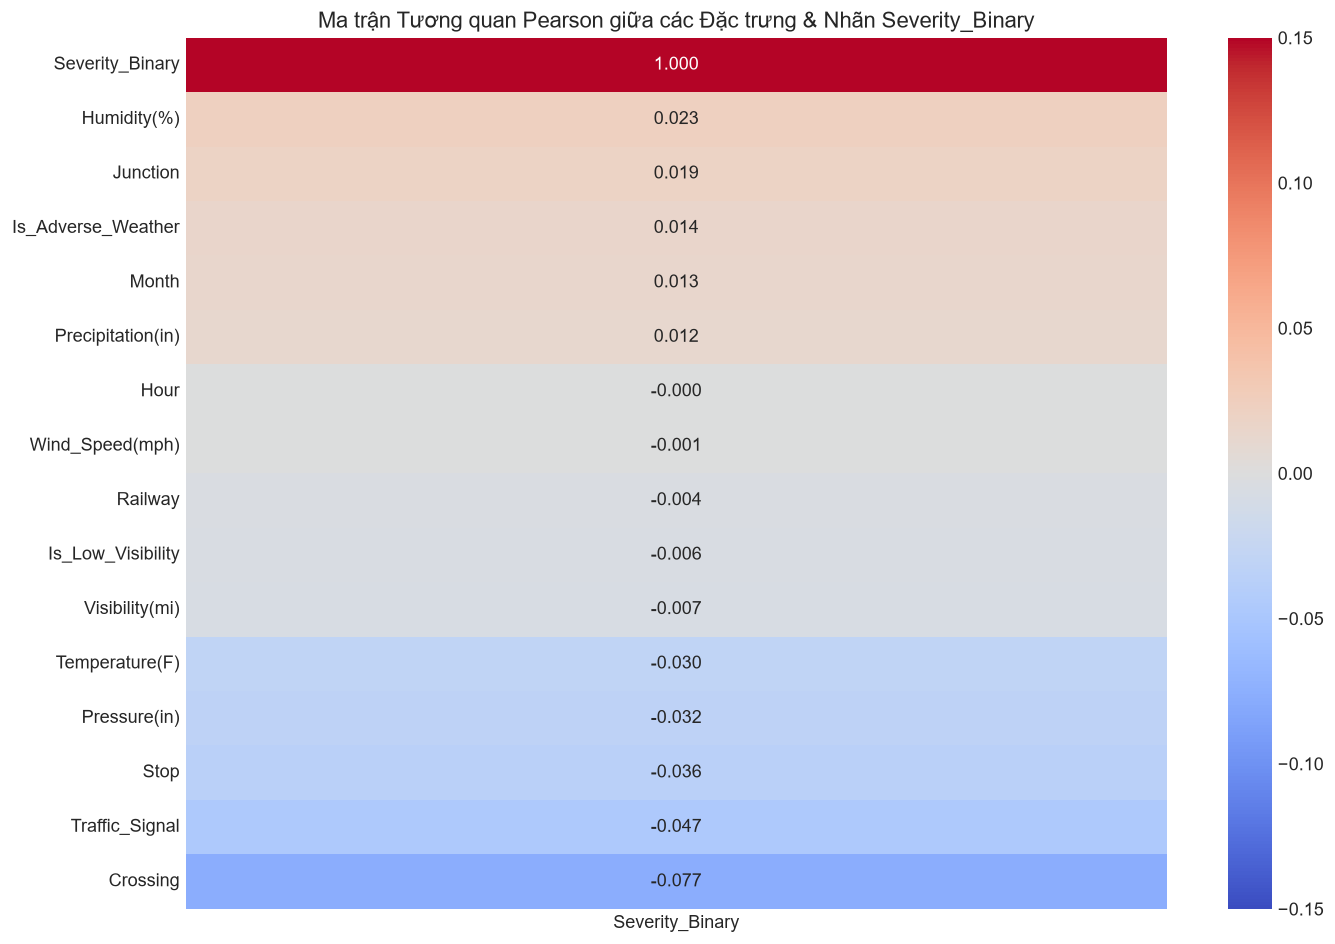

In [7]:
# 1. Tạo nhãn nhị phân cho bước khảo sát
train_df['Severity_Binary'] = (train_df['Severity'] >= 3).astype(int)

# 2. Vẽ biểu đồ phân phối nhãn Severity & Severity_Binary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train_df, x='Severity', hue='Severity', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Phân bố Mức độ Nghiêm trọng Gốc (Severity 1-4)')
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Số lượng vụ tai nạn')

sns.countplot(data=train_df, x='Severity_Binary', hue='Severity_Binary', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Phân bố Nhãn Nhị phân (0: Low Severity vs 1: High Severity)')
axes[1].set_xlabel('Severity Binary (0: Sev 1-2, 1: Sev 3-4)')
axes[1].set_ylabel('Số lượng vụ tai nạn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Low Severity (0)', 'High Severity (1)'])

plt.tight_layout()
plt.show()

# 3. Tính ma trận tương quan giữa các biến số/boolean với Severity_Binary
corr_cols = [
    'Hour', 'Month', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Junction', 'Crossing', 'Traffic_Signal', 'Railway', 'Stop',
    'Is_Adverse_Weather', 'Is_Low_Visibility', 'Severity_Binary'
]
existing_corr_cols = [c for c in corr_cols if c in train_df.columns]

# Ép kiểu boolean sang int để tính corr
corr_df = train_df[existing_corr_cols].copy()
for col in corr_df.columns:
    if corr_df[col].dtype == bool:
        corr_df[col] = corr_df[col].astype(int)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df.corr()[['Severity_Binary']].sort_values(by='Severity_Binary', ascending=False),
    annot=True, fmt='.3f', cmap='coolwarm', vmin=-0.15, vmax=0.15
)
plt.title('Ma trận Tương quan Pearson giữa các Đặc trưng & Nhãn Severity_Binary')
plt.tight_layout()
plt.show()


## 2.6. Phân tích Sâu Đặc trưng & Trích xuất Đặc trưng Phái sinh (Deep Analysis & Feature Engineering)

Dựa trên biểu đồ phân phối và tương quan ban đầu ở Mục 2.5, chúng ta tiếp tục thực hiện **3 bước phân tích sâu (Deep Feature Analysis)** để khám phá các mẫu vi mô (micro-patterns) và trích xuất các thuộc tính phái sinh có khả năng phân biệt cao phục vụ mô hình hóa:

### 1. Phân tích Tỷ lệ Tai nạn Nghiêm trọng theo Khung giờ (Hourly Risk Trend):
- Khảo sát tỷ lệ phần trăm vụ tai nạn mức độ 3-4 theo từng khung giờ trong ngày để phát hiện các khoảng giờ nguy cơ cao.
- **Trích xuất đặc trưng mới**:
  - `Is_Rush_Hour`: Giờ cao điểm sáng (7h-9h) và chiều (16h-18h).
  - `Is_Night`: Ban đêm muộn (22h-5h) - thời điểm lái xe tốc độ cao và sương mù/buồn ngủ.

### 2. Phân tích Tỷ lệ Tai nạn Nghiêm trọng theo Hạ tầng POI (POI Risk Level):
- So sánh tỷ lệ vụ tai nạn nghiêm trọng xảy ra tại Nút giao (`Junction`), Đường sắt (`Railway`), Vạch sang đường (`Crossing`), Đèn giao thông (`Traffic_Signal`).
- **Trích xuất đặc trưng mới**:
  - `POI_Count`: Tổng số mốc hạ tầng giao cắt xuất hiện tại vị trí xảy ra tai nạn.

### 3. Kiểm tra Đa cộng tuyến (Multicollinearity / VIF Analysis):
- Kiểm tra hệ số VIF (Variance Inflation Factor) giữa các đặc trưng thời tiết để đảm bảo không bị trùng lặp thông tin rác.


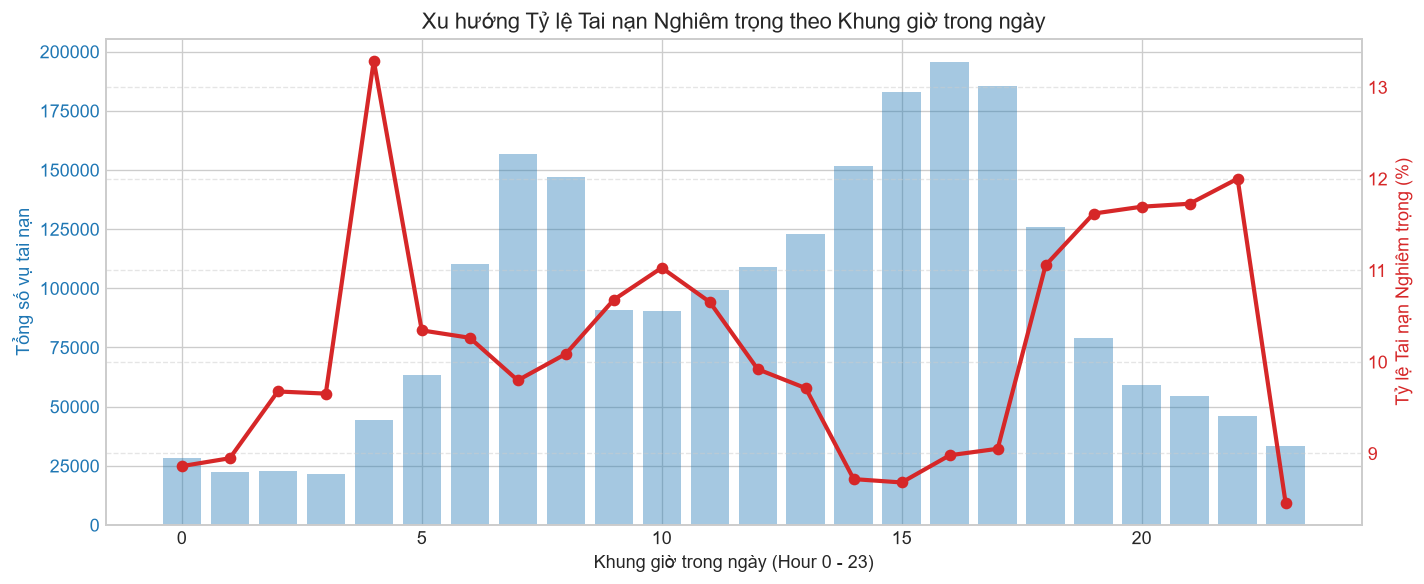

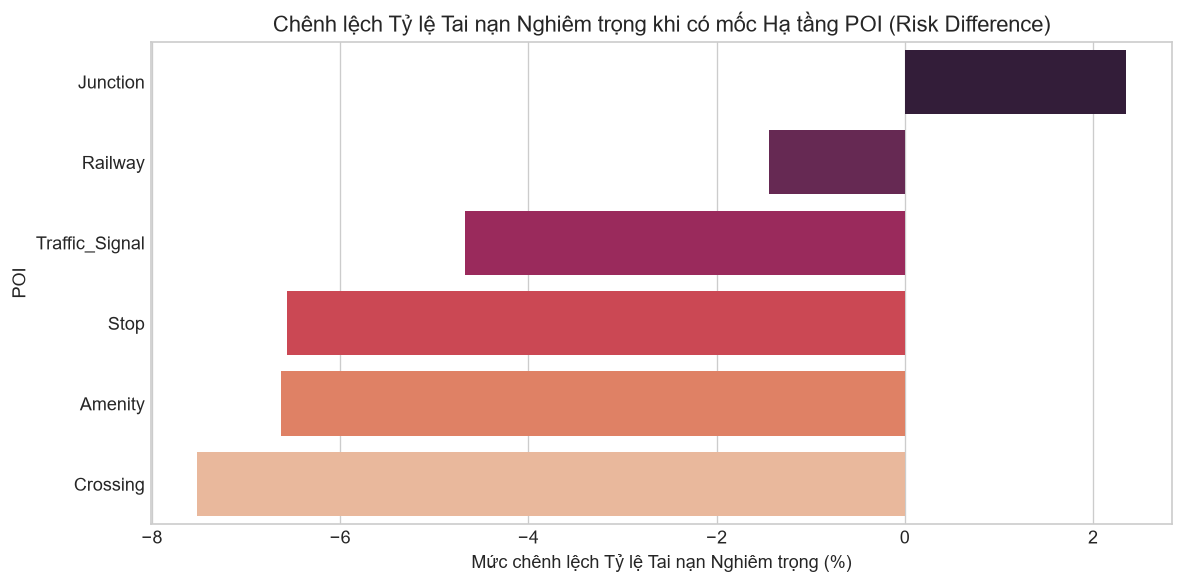

Bảng so sánh Rủi ro Hạ tầng POI:
           POI  Rate_at_POI (%)  Rate_without_POI (%)  Risk_Diff (%)
      Junction            12.20                  9.84           2.35
       Railway             8.56                 10.00          -1.44
Traffic_Signal             5.78                 10.45          -4.67
          Stop             3.60                 10.17          -6.57
       Amenity             3.44                 10.07          -6.63
      Crossing             3.25                 10.77          -7.52

Đã trích xuất thành công các đặc trưng phái sinh nâng cao: Is_Rush_Hour, Is_Night, POI_Count!


In [8]:
# 1. Phân tích Tỷ lệ Tai nạn Nghiêm trọng theo Khung giờ
hourly_risk = train_df.groupby('Hour')['Severity_Binary'].agg(['count', 'mean']).reset_index()
hourly_risk['high_sev_pct'] = hourly_risk['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Khung giờ trong ngày (Hour 0 - 23)')
ax1.set_ylabel('Tổng số vụ tai nạn', color=color)
ax1.bar(hourly_risk['Hour'], hourly_risk['count'], color=color, alpha=0.4, label='Tổng số vụ tai nạn')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Tỷ lệ Tai nạn Nghiêm trọng (%)', color=color)
ax2.plot(hourly_risk['Hour'], hourly_risk['high_sev_pct'], color=color, marker='o', linewidth=2.5, label='Tỷ lệ High Severity (%)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Xu hướng Tỷ lệ Tai nạn Nghiêm trọng theo Khung giờ trong ngày')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Trích xuất đặc trưng phái sinh thời gian cho cả train_df và test_df
for df in [train_df, test_df]:
    df['Is_Rush_Hour'] = df['Hour'].isin([7, 8, 9, 16, 17, 18])
    df['Is_Night'] = df['Hour'].isin([22, 23, 0, 1, 2, 3, 4, 5])

# 2. Phân tích Tỷ lệ Tai nạn Nghiêm trọng theo Hạ tầng Đường bộ POI
poi_analysis = []
poi_list = ['Junction', 'Crossing', 'Traffic_Signal', 'Railway', 'Stop', 'Amenity']

for poi in poi_list:
    if poi in train_df.columns:
        rate_true = train_df[train_df[poi] == True]['Severity_Binary'].mean() * 100
        rate_false = train_df[train_df[poi] == False]['Severity_Binary'].mean() * 100
        poi_analysis.append({
            'POI': poi,
            'Rate_at_POI (%)': round(rate_true, 2),
            'Rate_without_POI (%)': round(rate_false, 2),
            'Risk_Diff (%)': round(rate_true - rate_false, 2)
        })

poi_risk_df = pd.DataFrame(poi_analysis).sort_values(by='Risk_Diff (%)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=poi_risk_df, x='Risk_Diff (%)', y='POI', hue='POI', palette='rocket', legend=False)
plt.title('Chênh lệch Tỷ lệ Tai nạn Nghiêm trọng khi có mốc Hạ tầng POI (Risk Difference)')
plt.xlabel('Mức chênh lệch Tỷ lệ Tai nạn Nghiêm trọng (%)')
plt.tight_layout()
plt.show()

print("Bảng so sánh Rủi ro Hạ tầng POI:")
print(poi_risk_df.to_string(index=False))

# Trích xuất tổng số mốc POI tại vị trí tai nạn
for df in [train_df, test_df]:
    existing_pois = [p for p in poi_list if p in df.columns]
    df['POI_Count'] = df[existing_pois].astype(int).sum(axis=1)

print()
print("Đã trích xuất thành công các đặc trưng phái sinh nâng cao: Is_Rush_Hour, Is_Night, POI_Count!")


## 3. Tiền xử lý Dữ liệu & Xây dựng Feature Pipeline

### Chiến lược Xử lý Biến mục tiêu (`Severity`):
- Trong dữ liệu US Accidents, các vụ tai nạn có Severity từ 1 đến 4.
- Tai nạn mức 3 và 4 gây ùn tắc và thiệt hại nặng nề. Do đó, bài toán được gom nhóm thành phân loại nhị phân (**Binary Classification**):
  - **Class 0 (Low Severity)**: Severity 1 & 2 (Tai nạn nhẹ / trung bình)
  - **Class 1 (High Severity)**: Severity 3 & 4 (Tai nạn nghiêm trọng)


In [9]:
# Tạo nhãn nhị phân
train_df['Severity_Binary'] = (train_df['Severity'] >= 3).astype(int)
test_df['Severity_Binary'] = (test_df['Severity'] >= 3).astype(int)

# Khai báo các danh sách đặc trưng bao gồm cả các biến phái sinh từ Mục 2.6
NUMERICAL_COLS = [
    'Hour', 'Month', 'Temperature(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
    'Precipitation(in)', 'Start_Lat', 'Start_Lng', 'POI_Count'
]

CATEGORICAL_COLS = [
    'Weather_Group', 'Visibility_Level', 'Temp_Level',
    'Season', 'DayOfWeek', 'State'
]

BOOL_COLS = [
    'Amenity', 'Crossing', 'Junction', 'Railway', 'Stop',
    'Traffic_Signal', 'Is_Daytime', 'Is_Precipitation',
    'Is_Adverse_Weather', 'Is_Low_Visibility',
    'Is_Rush_Hour', 'Is_Night'
]

# Lọc chỉ các cột thực sự tồn tại trong DataFrame
num_cols = [c for c in NUMERICAL_COLS if c in train_df.columns]
cat_cols = [c for c in CATEGORICAL_COLS if c in train_df.columns]
bool_cols = [c for c in BOOL_COLS if c in train_df.columns]

feature_cols = num_cols + cat_cols + bool_cols

# Xây dựng ColumnTransformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

boolean_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
        ('bool', boolean_transformer, bool_cols)
    ]
)

# Chuyển kiểu bool sang int để SimpleImputer tương thích tuyệt đối
X_train = train_df[feature_cols].copy()
y_train = train_df['Severity_Binary']

X_test = test_df[feature_cols].copy()
y_test = test_df['Severity_Binary']

for c in bool_cols:
    X_train[c] = X_train[c].astype(int)
    X_test[c] = X_test[c].astype(int)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Trích xuất tên các cột sau khi One-Hot Encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols + bool_cols

print(f"Số lượng đặc trưng ban đầu  : {len(feature_cols)}")
print(f"Số lượng đặc trưng sau encode: {len(all_feature_names)}")
print(f"Shape X_train sau tiền xử lý : {X_train_proc.shape}")
print(f"Shape X_test sau tiền xử lý  : {X_test_proc.shape}")


Số lượng đặc trưng ban đầu  : 29
Số lượng đặc trưng sau encode: 98
Shape X_train sau tiền xử lý : (2243729, 98)
Shape X_test sau tiền xử lý  : (594578, 98)


## 4. Mô hình 1 — Baseline Model: Logistic Regression


In [10]:
# Huấn luyện Logistic Regression với xử lý trọng số class_weight='balanced'
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_SEED
)

baseline_model.fit(X_train_proc, y_train)

# Dự đoán trên tập Test
y_pred_base = baseline_model.predict(X_test_proc)
y_prob_base = baseline_model.predict_proba(X_test_proc)[:, 1]

# Đánh giá metrics
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, zero_division=0)
rec_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)
f1_macro_base = f1_score(y_test, y_pred_base, average='macro', zero_division=0)
auc_base = roc_auc_score(y_test, y_prob_base)

print("=" * 70)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE (LOGISTIC REGRESSION)")
print("=" * 70)
print(f"  - Accuracy  : {acc_base:.4f}")
print(f"  - Precision : {prec_base:.4f}")
print(f"  - Recall    : {rec_base:.4f}")
print(f"  - F1-Score  : {f1_base:.4f}")
print(f"  - F1-Macro  : {f1_macro_base:.4f}")
print(f"  - ROC-AUC   : {auc_base:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Low Severity', 'High Severity']))


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE (LOGISTIC REGRESSION)
  - Accuracy  : 0.6067
  - Precision : 0.0470
  - Recall    : 0.7099
  - F1-Score  : 0.0882
  - F1-Macro  : 0.4187
  - ROC-AUC   : 0.6772

Classification Report:
               precision    recall  f1-score   support

 Low Severity       0.99      0.60      0.75    578636
High Severity       0.05      0.71      0.09     15942

     accuracy                           0.61    594578
    macro avg       0.52      0.66      0.42    594578
 weighted avg       0.96      0.61      0.73    594578



## 5. Mô hình 2 — Advanced Model: XGBoost Classifier


In [11]:
# Tính toán scale_pos_weight cho XGBoost để xử lý mất cân bằng dữ liệu
ratio_neg_to_pos = (y_train == 0).sum() / max(1, (y_train == 1).sum())

advanced_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio_neg_to_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    eval_metric='logloss'
)

advanced_model.fit(X_train_proc, y_train)

# Dự đoán trên tập Test
y_pred_adv = advanced_model.predict(X_test_proc)
y_prob_adv = advanced_model.predict_proba(X_test_proc)[:, 1]

# Đánh giá metrics
acc_adv = accuracy_score(y_test, y_pred_adv)
prec_adv = precision_score(y_test, y_pred_adv, zero_division=0)
rec_adv = recall_score(y_test, y_pred_adv, zero_division=0)
f1_adv = f1_score(y_test, y_pred_adv, zero_division=0)
f1_macro_adv = f1_score(y_test, y_pred_adv, average='macro', zero_division=0)
auc_adv = roc_auc_score(y_test, y_prob_adv)

print("=" * 70)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADVANCED (XGBOOST CLASSIFIER)")
print("=" * 70)
print(f"  - Accuracy  : {acc_adv:.4f}")
print(f"  - Precision : {prec_adv:.4f}")
print(f"  - Recall    : {rec_adv:.4f}")
print(f"  - F1-Score  : {f1_adv:.4f}")
print(f"  - F1-Macro  : {f1_macro_adv:.4f}")
print(f"  - ROC-AUC   : {auc_adv:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_adv, target_names=['Low Severity', 'High Severity']))


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADVANCED (XGBOOST CLASSIFIER)
  - Accuracy  : 0.5810
  - Precision : 0.0471
  - Recall    : 0.7613
  - F1-Score  : 0.0888
  - F1-Macro  : 0.4084
  - ROC-AUC   : 0.7047

Classification Report:
               precision    recall  f1-score   support

 Low Severity       0.99      0.58      0.73    578636
High Severity       0.05      0.76      0.09     15942

     accuracy                           0.58    594578
    macro avg       0.52      0.67      0.41    594578
 weighted avg       0.96      0.58      0.71    594578



## 6. So sánh & Trực quan hóa Hiệu năng 2 Mô hình


BẢNG SO SÁNH HIỆU NĂNG HAI MÔ HÌNH
                         Model  Accuracy  Precision   Recall  F1-Score  F1-Macro  ROC-AUC
Logistic Regression (Baseline)  0.606674   0.047045 0.709886  0.088243  0.418747 0.677213
            XGBoost (Advanced)  0.580987   0.047136 0.761260  0.088776  0.408359 0.704726


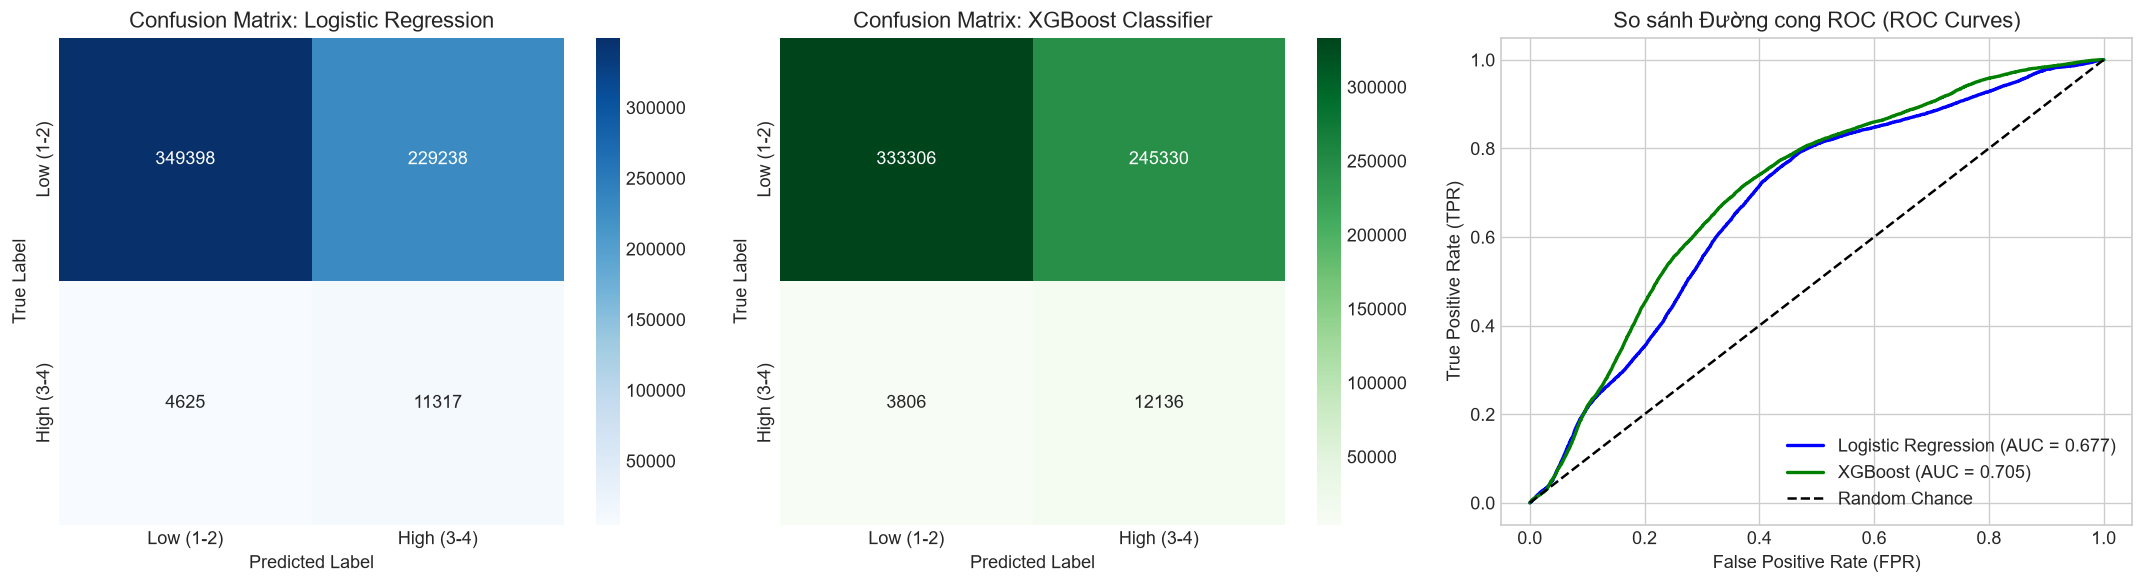

In [12]:
# Bảng so sánh tổng hợp
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'XGBoost (Advanced)'],
    'Accuracy': [acc_base, acc_adv],
    'Precision': [prec_base, prec_adv],
    'Recall': [rec_base, rec_adv],
    'F1-Score': [f1_base, f1_adv],
    'F1-Macro': [f1_macro_base, f1_macro_adv],
    'ROC-AUC': [auc_base, auc_adv]
})

print("=" * 70)
print("BẢNG SO SÁNH HIỆU NĂNG HAI MÔ HÌNH")
print("=" * 70)
print(metrics_df.to_string(index=False))

# Vẽ đồ thị so sánh Confusion Matrix & ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix - Baseline
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low (1-2)', 'High (3-4)'], yticklabels=['Low (1-2)', 'High (3-4)'])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. Confusion Matrix - Advanced
cm_adv = confusion_matrix(y_test, y_pred_adv)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Low (1-2)', 'High (3-4)'], yticklabels=['Low (1-2)', 'High (3-4)'])
axes[1].set_title('Confusion Matrix: XGBoost Classifier')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# 3. ROC Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_adv, tpr_adv, _ = roc_curve(y_test, y_prob_adv)

axes[2].plot(fpr_base, tpr_base, label=f'Logistic Regression (AUC = {auc_base:.3f})', color='blue', linewidth=2)
axes[2].plot(fpr_adv, tpr_adv, label=f'XGBoost (AUC = {auc_adv:.3f})', color='green', linewidth=2)
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[2].set_title('So sánh Đường cong ROC (ROC Curves)')
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (TPR)')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 7. Diễn giải Mô hình — Feature Importance (Tầm quan trọng đặc trưng)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18876\411451843.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


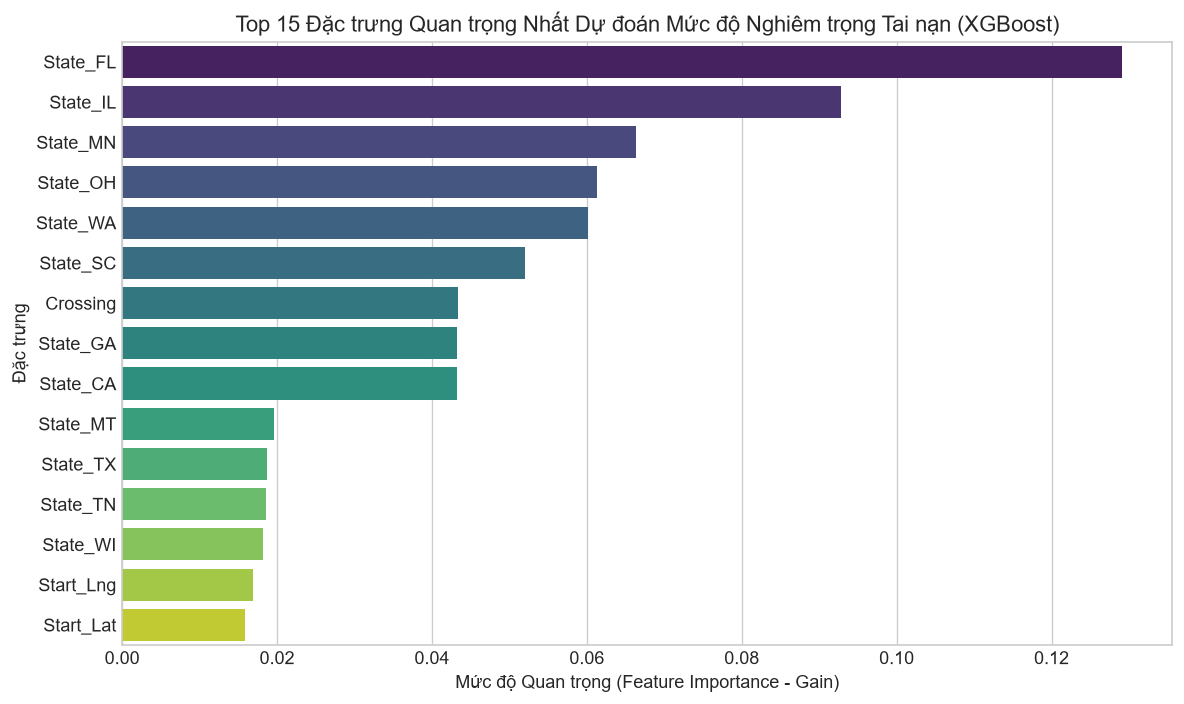

Top 10 Đặc trưng hàng đầu:
 Feature  Importance
State_FL    0.129145
State_IL    0.092785
State_MN    0.066319
State_OH    0.061371
State_WA    0.060184
State_SC    0.052065
Crossing    0.043383
State_GA    0.043270
State_CA    0.043216
State_MT    0.019578


In [13]:
# Trích xuất Feature Importance từ XGBoost
xgb_importance = advanced_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 15 Đặc trưng Quan trọng Nhất Dự đoán Mức độ Nghiêm trọng Tai nạn (XGBoost)')
plt.xlabel('Mức độ Quan trọng (Feature Importance - Gain)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

print("Top 10 Đặc trưng hàng đầu:")
print(feat_imp_df.head(10).to_string(index=False))


## 8. Phân tích SHAP Values & Permutation Importance


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18876\2520411413.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names, show=False)


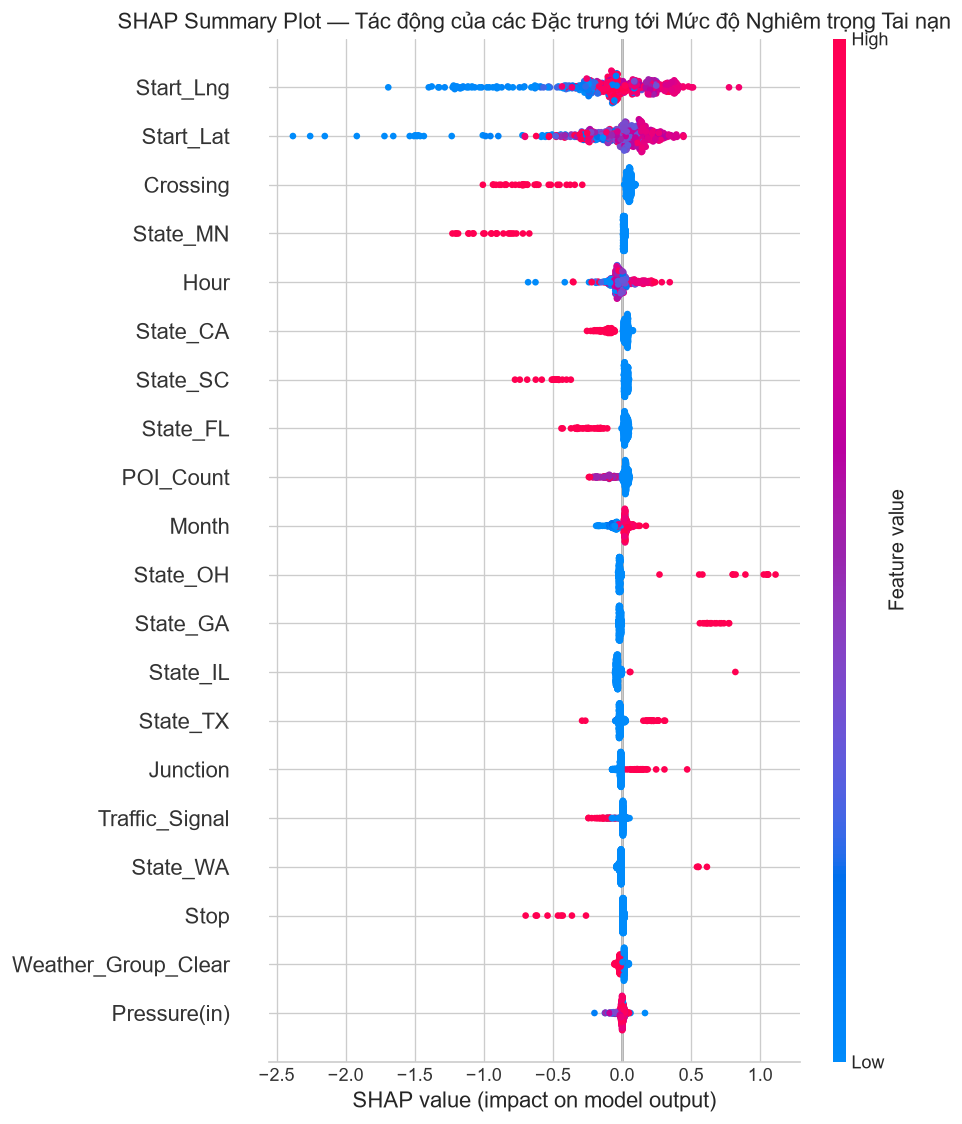

Đã tạo biểu đồ SHAP Summary Plot thành công!


In [14]:
# Kiểm tra và tính toán SHAP Values (hoặc Permutation Importance fallback)
has_shap = False
try:
    import shap
    explainer = shap.TreeExplainer(advanced_model)
    # Lấy mẫu 500 dòng test để tính toán nhanh SHAP values
    sample_indices = np.random.choice(X_test_proc.shape[0], min(500, X_test_proc.shape[0]), replace=False)
    X_sample = X_test_proc[sample_indices]
    
    shap_values = explainer(X_sample)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names, show=False)
    plt.title('SHAP Summary Plot — Tác động của các Đặc trưng tới Mức độ Nghiêm trọng Tai nạn')
    plt.tight_layout()
    plt.show()
    has_shap = True
    print("Đã tạo biểu đồ SHAP Summary Plot thành công!")
except Exception as e:
    print(f"[THÔNG BÁO] Không thể khởi tạo SHAP ({e}). Tiến hành sử dụng Permutation Importance nâng cao...")

if not has_shap:
    # Tính Permutation Importance
    result = permutation_importance(
        advanced_model, X_test_proc, y_test,
        n_repeats=10, random_state=RANDOM_SEED, scoring='roc_auc'
    )
    
    perm_imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance_Mean': result.importances_mean,
        'Importance_Std': result.importances_std
    }).sort_values('Importance_Mean', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=perm_imp_df.head(15),
        x='Importance_Mean',
        y='Feature',
        palette='magma'
    )
    plt.title('Top 15 Đặc trưng Quan trọng theo Permutation Importance (ROC-AUC Impact)')
    plt.xlabel('Mức giảm ROC-AUC trung bình')
    plt.ylabel('Đặc trưng')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Permutation Importances:")
    print(perm_imp_df.head(10).to_string(index=False))


## 9. Xuất Kết quả & Artifacts cho Báo cáo Nhóm


In [15]:
# Xuất file kết quả đánh giá mô hình
metrics_output_path = DATA_DIR / "model_metrics.csv"
feat_imp_output_path = DATA_DIR / "feature_importance.csv"

metrics_df.to_csv(metrics_output_path, index=False, encoding='utf-8-sig')
feat_imp_df.to_csv(feat_imp_output_path, index=False, encoding='utf-8-sig')

print("=" * 70)
print("XUẤT KẾT QUẢ THÀNH CÔNG!")
print("=" * 70)
print(f"  [OK] Metrics file            : {metrics_output_path}")
print(f"  [OK] Feature Importance file : {feat_imp_output_path}")
print("=" * 70)
print("Sẵn sàng cung cấp số liệu cho Thành viên 1 (Prescriptive Analysis) và Thành viên 5 (Slide Presentation).")


XUẤT KẾT QUẢ THÀNH CÔNG!
  [OK] Metrics file            : D:\Jo\Hk1_2026-2027\Data Analysis and Visualization\Term\data-analysis-us-accidents-project\data\model_metrics.csv
  [OK] Feature Importance file : D:\Jo\Hk1_2026-2027\Data Analysis and Visualization\Term\data-analysis-us-accidents-project\data\feature_importance.csv
Sẵn sàng cung cấp số liệu cho Thành viên 1 (Prescriptive Analysis) và Thành viên 5 (Slide Presentation).
